In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, QuantileTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import keras_tuner as kt

In [2]:
dat = pd.read_csv('../Data/bird.csv')
# --- 1. Preprocessing (as before, but with minor adjustments) ---
if 'id' in dat.columns:
    dat = dat.drop('id', axis=1)

dat.dropna(axis=0, inplace=True) # Drop rows with any missing values

for col in dat.columns[:-1]:
    percentile_95 = dat[col].quantile(0.95)
    dat[col] = np.where(dat[col] > percentile_95, percentile_95, dat[col])

X = dat.iloc[:, :-1]
y = dat.iloc[:, -1]

# Use QuantileTransformer to handle non-Gaussian distributions
qt = QuantileTransformer(output_distribution='normal', n_quantiles=dat.shape[1])
X_transformed = qt.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled_encoded = smote.fit_resample(X_transformed, y_encoded)

# Split data
X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X_resampled, y_resampled_encoded, test_size=0.2, random_state=42, stratify=y_resampled_encoded
)
y_train_cat = keras.utils.to_categorical(y_train_enc)
y_test_cat = keras.utils.to_categorical(y_test_enc)


In [3]:

# --- 2. Calculate Class Weights ---
# This provides an alternative way to handle imbalance during training
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weights_dict = dict(enumerate(class_weights))
print("Calculated Class Weights:", class_weights_dict)


Calculated Class Weights: {0: np.float64(0.9916666666666667), 1: np.float64(1.0016835016835017), 2: np.float64(1.0016835016835017), 3: np.float64(1.0016835016835017), 4: np.float64(1.0016835016835017), 5: np.float64(1.0016835016835017)}


In [4]:

# --- 3. Hyperparameter Tuning with KerasTuner ---
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))

    # Tune the number of hidden layers and neurons
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            activation=hp.Choice(f'activation_{i}', ['relu', 'tanh'])
        ))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Dropout(hp.Float(f'dropout_{i}', 0.2, 0.5, step=0.1)))

    model.add(keras.layers.Dense(y_train_cat.shape[1], activation='softmax'))

    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [5]:

# Instantiate the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10, # Number of different hyperparameter combinations to try
    executions_per_trial=3, # Number of models to train for each combination
    directory='keras_tuner_dir',
    project_name='bird_classification'
)


Reloading Tuner from keras_tuner_dir\bird_classification\tuner0.json


In [6]:

# Search for the best hyperparameters
tuner.search(X_train, y_train_cat, epochs=50, validation_split=0.2, verbose=1)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Best Hyperparameters Found:
- Number of layers: {best_hps.get('num_layers')}
- Learning rate: {best_hps.get('learning_rate')}
""")

# Build the model with the optimal hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


Best Hyperparameters Found:
- Number of layers: 1
- Learning rate: 0.01




c:\Users\zaid.n.ansari\Desktop\Models\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,694 (10.52 KB)

 Trainable params: 2,438 (9.52 KB)

 Non-trainable params: 256 (1.00 KB)

In [7]:

# --- 4. Advanced Training with Callbacks ---
# Define callbacks for smarter training
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15, # Stop if val_loss doesn't improve for 15 epochs
    restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # Reduce lr by a factor of 5
    patience=5,
    min_lr=1e-6
)


In [8]:

# Train the best model using class weights and callbacks
history = best_model.fit(
    X_train,
    y_train_cat,
    epochs=150, # A higher number, since EarlyStopping will find the optimal point
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8461 - loss: 0.4897 - val_accuracy: 0.8655 - val_loss: 0.6190 - learning_rate: 0.0100
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8260 - loss: 0.5606 - val_accuracy: 0.8908 - val_loss: 0.4673 - learning_rate: 0.0100
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8687 - loss: 0.3484 - val_accuracy: 0.8824 - val_loss: 0.3811 - learning_rate: 0.0100
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9049 - loss: 0.2506 - val_accuracy: 0.8992 - val_loss: 0.5000 - learning_rate: 0.0100
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8941 - loss: 0.2920 - val_accuracy: 0.9160 - val_loss: 0.4321 - learning_rate: 0.0100
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8755 - loss: 0.3239 - val_accuracy: 0.8824 - val_loss: 0.5653 - learning_rate: 0.0100
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9195 - loss: 0.2524 - val_a

In [9]:

# --- 5. Final Evaluation ---
loss, accuracy = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\nFinal Test Accuracy on Tuned Model: {accuracy*100:.2f}%')

y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=label_encoder.classes_))



Final Test Accuracy on Tuned Model: 95.30%
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step 

Classification Report:
              precision    recall  f1-score   support

           P       0.95      0.88      0.91        24
           R       1.00      1.00      1.00        25
          SO       1.00      0.96      0.98        25
          SW       0.96      0.92      0.94        25
           T       1.00      1.00      1.00        25
           W       0.83      0.96      0.89        25

    accuracy                           0.95       149
   macro avg       0.96      0.95      0.95       149
weighted avg       0.96      0.95      0.95       149



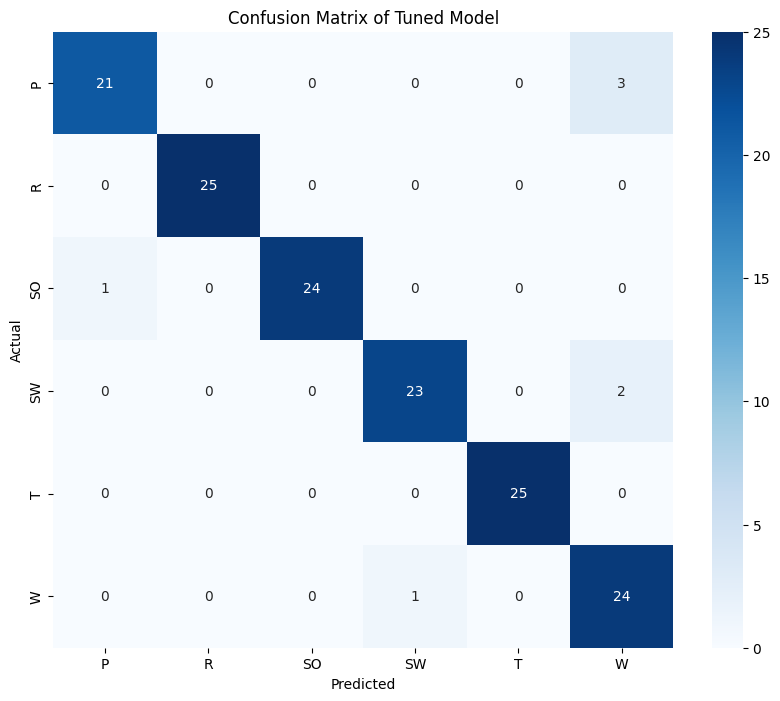

In [10]:

cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix of Tuned Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
